Random_state:  63
              precision    recall  f1-score   support

 non-healing       1.00      0.50      0.67         2
     healing       0.86      1.00      0.92         6

   micro avg       0.88      0.88      0.88         8
   macro avg       0.93      0.75      0.79         8
weighted avg       0.89      0.88      0.86         8
 samples avg       0.88      0.88      0.88         8



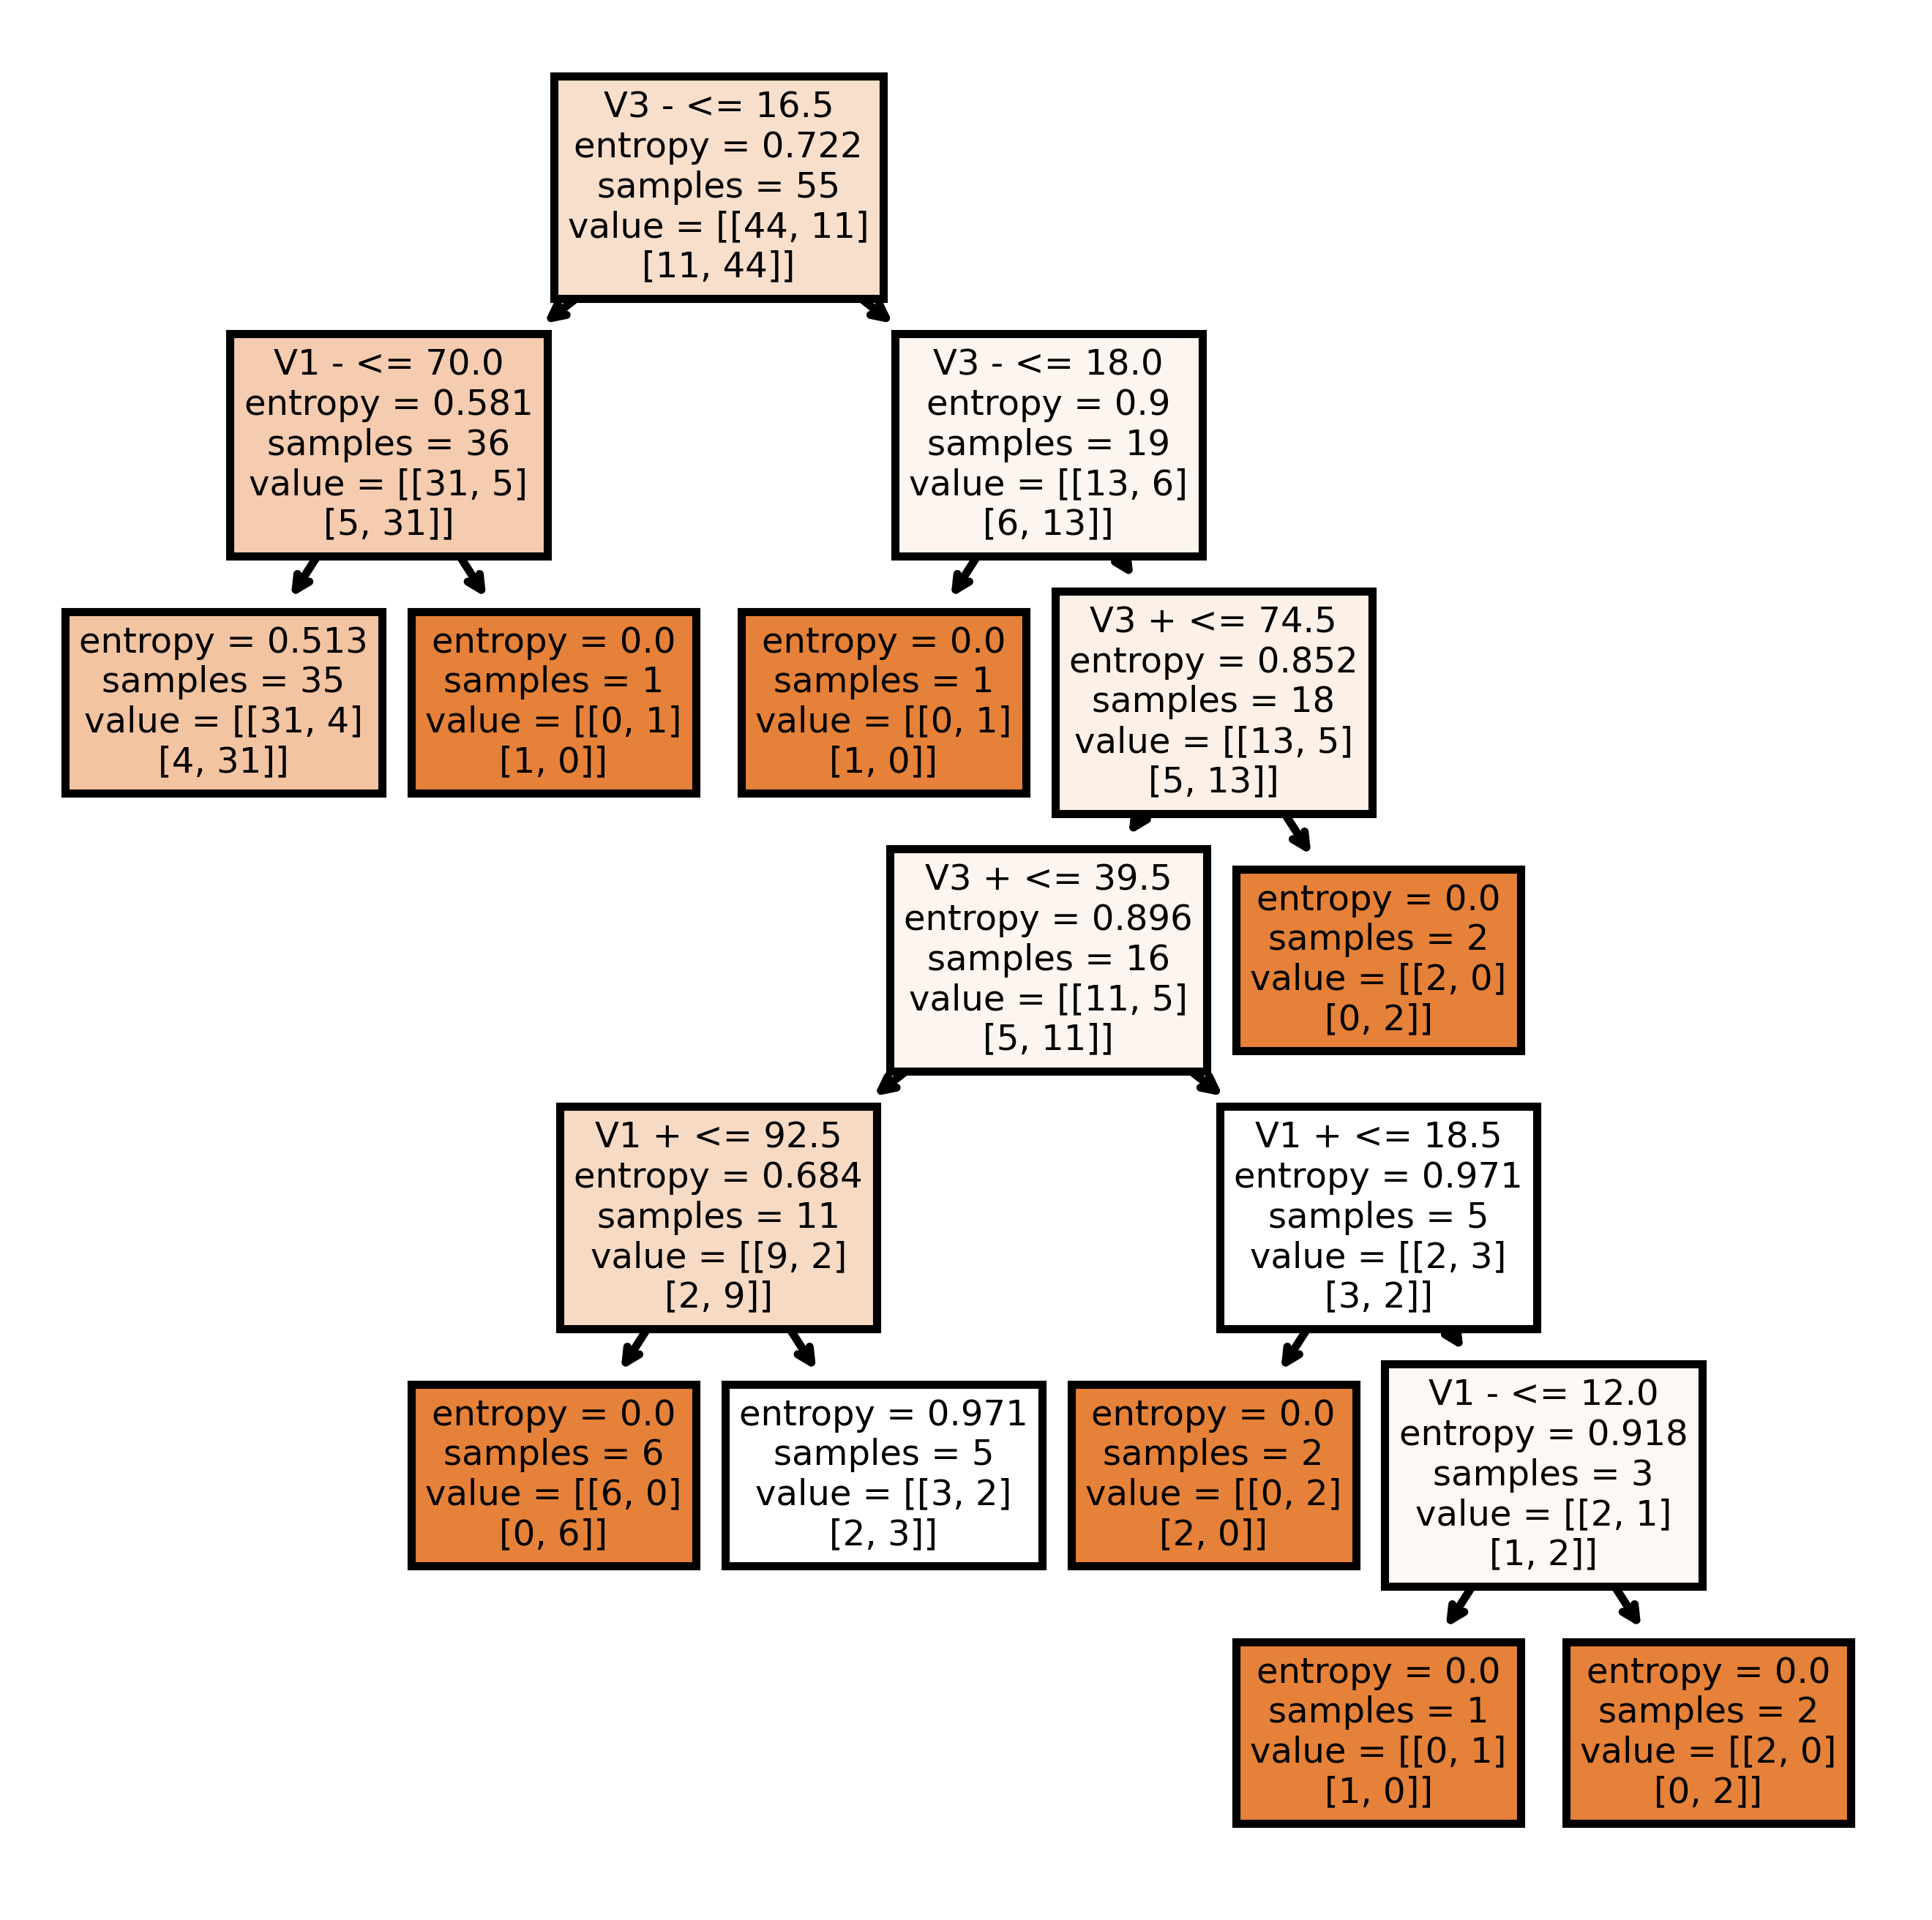

Accuracy: 87.5 %


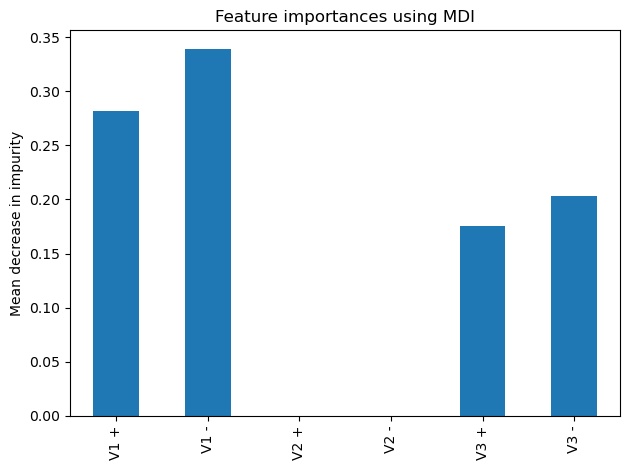

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import random
from tensorflow.keras.utils import to_categorical
from sklearn.tree import DecisionTreeClassifier

Treatment=pd.read_csv("../dissertation/plus Gran1-3.csv")
df_x=Treatment.iloc[:,1:]
df_y=Treatment.iloc[:,0]
R_state=random.randrange(1,100)
print("Random_state: ",R_state)
R_state=29
X_train, X_test, y_train, y_test = train_test_split(df_x, df_y,test_size=0.12, random_state=R_state,stratify=df_y)
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)



names=["V1 +","V1 -", "V2 +","V2 -", "V3 +", "V3 -"]
clf=DecisionTreeClassifier(#max_depth=None,
                            #class_weight="balanced",
                               criterion="entropy",
                              ccp_alpha=0.03,
                  
    )

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_pred = (y_pred > 0.5) 

print(classification_report(y_test,y_pred,output_dict=False,target_names=["non-healing","healing"]))

fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=800)
tree.plot_tree(clf, filled = True,feature_names=names);
plt.savefig('Tree', dpi=1200)
plt.show()

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", (accuracy*100),"%")

importances = clf.feature_importances_
forest_importances = pd.Series(importances, index=names)
fig, ax = plt.subplots()
forest_importances.plot.bar( ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()
plt.show()
target = 'key'
class_names=["non-healing","healing"]

from supertree import SuperTree
st = SuperTree(
    clf, 
    df_x, 
    df_y, 
    names, 
    class_names
)
# Visualize the tree
st.show_tree()